In [3]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import time
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

BASE = r"C:\Users\paola\Tesis"
SST_FILE = os.path.join(BASE, r"02_Procesados\SST_monthly_detrended_1981_2025_0p5deg.nc")

bestcluster_files = {
    "maize":   os.path.join(BASE, r"02_Procesados\maize_bestcluster.nc"),
    "rice":    os.path.join(BASE, r"02_Procesados\rice_bestcluster.nc"),
    "wheat":   os.path.join(BASE, r"02_Procesados\wheat_bestcluster.nc"),
    "soybean": os.path.join(BASE, r"02_Procesados\soybean_bestcluster.nc"),
}

# ============================================================
# PEARSON REAL
# ============================================================

from scipy.stats import pearsonr

def pearson_full(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        return np.nan, np.nan
    r, p = pearsonr(x[mask], y[mask])
    return r, p


# ============================================================
# CORRELACIONAR SOLO 1 PUNTO Y MEDIR TIEMPO
# ============================================================

cultivo = "maize"    # <-- AQUÍ escoges uno
ruta = bestcluster_files[cultivo]

print(f"\n========== CULTIVO SELECCIONADO: {cultivo.upper()} ==========")

# ------------------------------------------------------------
# Cargar rendimiento del bestcluster
# ------------------------------------------------------------
ds_y = xr.open_dataset(ruta)
var_y = list(ds_y.data_vars)[0]
da = ds_y[var_y]

# Arreglar tiempo si no es datetime
if not np.issubdtype(da.time.dtype, np.datetime64):
    da = da.assign_coords(time=pd.to_datetime(np.arange(1981,1981+da.sizes["time"]), format="%Y"))

# Pixeles válidos
mask = np.any(~np.isnan(da), axis=0)
lat_idx, lon_idx = np.where(mask)

# Punto random
k = np.random.randint(0, len(lat_idx))
i, j = lat_idx[k], lon_idx[k]

lat_sel = float(da.lat[i])
lon_sel = float(da.lon[j])

print(f"\n📌 Pixel seleccionado:")
print(f"   → lat = {lat_sel:.2f}")
print(f"   → lon = {lon_sel:.2f}")

# Serie temporal del rendimiento
serie_y = da[:, i, j]
y_pix = (serie_y - serie_y.mean()) / serie_y.std()

# ------------------------------------------------------------
# Cargar SST
# ------------------------------------------------------------
ds_sst = xr.open_dataset(SST_FILE)
var_sst = list(ds_sst.data_vars)[0]

sst = ds_sst[var_sst].sel(time=slice("1981","2016"))
sst = sst.assign_coords(
    year=sst.time.dt.year,
    month=sst.time.dt.month
)

# ------------------------------------------------------------
# CORRELACIÓN MENSUAL — MEDIR TIEMPO
# ------------------------------------------------------------
start = time.time()

r_list, p_list = [], []

print("\n⏳ Progreso:", end=" ")

for m in range(1, 13):

    # porcentaje
    progreso = int((m/12)*100)
    print(f"\r⏳ Progreso: {progreso}%   ", end="")

    # SST del mes M
    sst_m = sst.where(sst.month == m, drop=True).groupby("year").mean("time")

    # Años comunes
    years = np.intersect1d(sst_m.year.values, y_pix.time.dt.year.values)

    sst_c = sst_m.sel(year=years)
    y_c   = y_pix.sel(time=pd.to_datetime(years, format="%Y"))

    # Pearson punto-campo (vectorizado)
    r_map, p_map = xr.apply_ufunc(
        pearson_full,
        sst_c,
        y_c,
        input_core_dims=[["year"], ["time"]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float]
    )

    r_list.append(r_map)
    p_list.append(p_map)

print("\r⏳ Progreso: 100% ✔")

end = time.time()
total_time = end - start

print(f"\n🕒 Tiempo total de correlación para 1 pixel: {total_time:.2f} segundos\n")

# ------------------------------------------------------------
# Dataset final (sin guardar nada)
# ------------------------------------------------------------

corr = xr.concat(r_list, dim="month").assign_coords(month=np.arange(1,13))
pval = xr.concat(p_list, dim="month").assign_coords(month=np.arange(1,13))

print("✔ correlación lista (no graficada, no guardada).")



========== CULTIVO SELECCIONADO: MAIZE ==========

📌 Pixel seleccionado:
   → lat = 41.75
   → lon = 279.75

⏳ Progreso: 100% ✔ 

🕒 Tiempo total de correlación para 1 pixel: 1058.81 segundos

✔ correlación lista (no graficada, no guardada).


In [ ]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import time
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

BASE = r"C:\Users\paola\Tesis"

SST_FILE = os.path.join(
    BASE, r"02_Procesados\SST_monthly_detrended_1981_2025_0p5deg.nc"
)

BESTCLUSTER_FILE = os.path.join(
    BASE, r"02_Procesados\rice_bestcluster.nc"      # <-- SOLO RICE
)

OUTDIR = os.path.join(
    BASE, r"03_Resultados\Correlaciones_fast\rice_batches"
)
os.makedirs(OUTDIR, exist_ok=True)

# Cuántos píxeles por batch
BATCH_SIZE = 531


# ============================================================
# PEARSON REAL EXACTO
# ============================================================

from scipy.stats import pearsonr

def pearson_full(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        return np.nan, np.nan
    r, p = pearsonr(x[mask], y[mask])
    return r, p


# ============================================================
# FUNCION PRINCIPAL DEL BATCH
# ============================================================

def correr_batch(batch_id, start_idx, end_idx):

    print(f"\n=============== BATCH {batch_id} ===============")
    print(f"Procesando píxeles {start_idx} → {end_idx-1}")

    # ------------------ CARGAR YIELD ------------------
    ds_y = xr.open_dataset(BESTCLUSTER_FILE)
    var_y = list(ds_y.data_vars)[0]
    da = ds_y[var_y]

    if not np.issubdtype(da.time.dtype, np.datetime64):
        da = da.assign_coords(
            time=pd.to_datetime(np.arange(1981, 1981+da.sizes["time"]), format="%Y")
        )

    mask = np.any(~np.isnan(da), axis=0)
    lat_idx, lon_idx = np.where(mask)

    # Lista total de pixeles
    total_pix = len(lat_idx)

    # Limitar batch
    end_idx = min(end_idx, total_pix)
    batch_pixels = list(zip(lat_idx[start_idx:end_idx], lon_idx[start_idx:end_idx]))


    # ------------------ CARGAR SST ------------------
    ds_sst = xr.open_dataset(SST_FILE)
    var_sst = list(ds_sst.data_vars)[0]

    sst = ds_sst[var_sst].sel(time=slice("1981", "2016"))
    sst = sst.assign_coords(
        year=sst.time.dt.year,
        month=sst.time.dt.month
    )


    # ======================================================
    # CORRELACIÓN PARA CADA PIXEL DEL BATCH
    # ======================================================
    resultados = []

    total_batch = len(batch_pixels)
    print(f"Total en batch: {total_batch}")

    for n, (i, j) in enumerate(batch_pixels):

        progreso = int( (n+1)/total_batch * 100 )
        print(f"\r⏳ Avance batch: {progreso}%   ({n+1}/{total_batch})", end="")

        lat_sel = float(da.lat[i])
        lon_sel = float(da.lon[j])

        serie_y = da[:, i, j]
        y_pix = (serie_y - serie_y.mean()) / serie_y.std()

        # Correlación por los 12 meses
        r_list, p_list = [], []

        for m in range(1, 13):
            sst_m = sst.where(sst.month == m, drop=True).groupby("year").mean("time")

            years = np.intersect1d(sst_m.year.values, y_pix.time.dt.year.values)

            sst_c = sst_m.sel(year=years)
            y_c   = y_pix.sel(time=pd.to_datetime(years, format="%Y"))

            r_map, p_map = xr.apply_ufunc(
                pearson_full,
                sst_c,
                y_c,
                input_core_dims=[["year"], ["time"]],
                output_core_dims=[[], []],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[float, float]
            )

            r_list.append(r_map)
            p_list.append(p_map)

        corr = xr.concat(r_list, dim="month").assign_coords(month=np.arange(1,13))
        pval = xr.concat(p_list, dim="month").assign_coords(month=np.arange(1,13))

        # Guardar resultado por pixel en lista
        resultados.append({
            "lat": lat_sel,
            "lon": lon_sel,
            "corr": corr,
            "pval": pval
        })

    print("\n✔ Batch calculado.")


    # ======================================================
    # GUARDAR ARCHIVO .nc DEL BATCH
    # ======================================================
    # Estructura:
    # month × pixel × lat × lon  (pero colapsamos a pixel index)

    ds_out = xr.Dataset()

    # crear variables por pixel
    for k, res in enumerate(resultados):
        ds_out[f"corr_{k}"] = res["corr"]
        ds_out[f"pval_{k}"] = res["pval"]
        ds_out[f"lat_{k}"] = xr.DataArray(res["lat"])
        ds_out[f"lon_{k}"] = xr.DataArray(res["lon"])

    outfile = os.path.join(OUTDIR, f"rice_batch_{batch_id}.nc")
    ds_out.to_netcdf(outfile)

    print(f"📁 Archivo guardado: {outfile}")

# ============================================================
# EJECUTAR UN BATCH MANUALMENTE
# ============================================================

# ejemplo: primer batch de 531 píxeles
correr_batch(
    batch_id=1,
    start_idx=0,
    end_idx=531
)



=============== BATCH 1 ===============
Procesando píxeles 0 → 530
Total en batch: 531
⏳ Avance batch: 0%   (1/531)

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import time
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

BASE = r"C:\Users\paola\Tesis"

SST_FILE = os.path.join(
    BASE, r"02_Procesados\SST_monthly_detrended_1981_2025_0p5deg.nc"
)

BESTCLUSTER_FILE = os.path.join(
    BASE, r"02_Procesados\rice_bestcluster.nc"      # <-- SOLO RICE
)

OUTDIR = os.path.join(
    BASE, r"03_Resultados\Correlaciones_fast\rice_batches"
)
os.makedirs(OUTDIR, exist_ok=True)

# Cuántos píxeles por batch
BATCH_SIZE = 20


# ============================================================
# PEARSON REAL EXACTO
# ============================================================

from scipy.stats import pearsonr

def pearson_full(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        return np.nan, np.nan
    r, p = pearsonr(x[mask], y[mask])
    return r, p


# ============================================================
# FUNCION PRINCIPAL DEL BATCH
# ============================================================

def correr_batch(batch_id, start_idx, end_idx):

    print(f"\n=============== BATCH {batch_id} ===============")
    print(f"Procesando píxeles {start_idx} → {end_idx-1}")

    # ------------------ CARGAR YIELD ------------------
    ds_y = xr.open_dataset(BESTCLUSTER_FILE)
    var_y = list(ds_y.data_vars)[0]
    da = ds_y[var_y]

    if not np.issubdtype(da.time.dtype, np.datetime64):
        da = da.assign_coords(
            time=pd.to_datetime(np.arange(1981, 1981+da.sizes["time"]), format="%Y")
        )

    mask = np.any(~np.isnan(da), axis=0)
    lat_idx, lon_idx = np.where(mask)

    total_pix = len(lat_idx)

    # Limitar batch
    end_idx = min(end_idx, total_pix)
    batch_pixels = list(zip(lat_idx[start_idx:end_idx], lon_idx[start_idx:end_idx]))


    # ------------------ CARGAR SST ------------------
    ds_sst = xr.open_dataset(SST_FILE)
    var_sst = list(ds_sst.data_vars)[0]

    sst = ds_sst[var_sst].sel(time=slice("1981", "2016"))
    sst = sst.assign_coords(
        year=sst.time.dt.year,
        month=sst.time.dt.month
    )


    # ======================================================
    # CORRELACIÓN PARA CADA PIXEL DEL BATCH
    # ======================================================
    resultados = []

    total_batch = len(batch_pixels)
    print(f"Total en batch: {total_batch}")

    for n, (i, j) in enumerate(batch_pixels):

        progreso = int( (n+1)/total_batch * 100 )
        print(f"\r⏳ Avance batch: {progreso}%   ({n+1}/{total_batch})", end="")

        lat_sel = float(da.lat[i])
        lon_sel = float(da.lon[j])

        serie_y = da[:, i, j]
        y_pix = (serie_y - serie_y.mean()) / serie_y.std()

        # Correlación por los 12 meses
        r_list, p_list = [], []

        for m in range(1, 13):
            sst_m = sst.where(sst.month == m, drop=True).groupby("year").mean("time")

            years = np.intersect1d(sst_m.year.values, y_pix.time.dt.year.values)

            sst_c = sst_m.sel(year=years)
            y_c   = y_pix.sel(time=pd.to_datetime(years, format="%Y"))

            r_map, p_map = xr.apply_ufunc(
                pearson_full,
                sst_c,
                y_c,
                input_core_dims=[["year"], ["time"]],
                output_core_dims=[[], []],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[float, float]
            )

            r_list.append(r_map)
            p_list.append(p_map)

        corr = xr.concat(r_list, dim="month").assign_coords(month=np.arange(1,13))
        pval = xr.concat(p_list, dim="month").assign_coords(month=np.arange(1,13))

        resultados.append({
            "lat": lat_sel,
            "lon": lon_sel,
            "corr": corr,
            "pval": pval
        })

    print("\n✔ Batch calculado.")


    # ======================================================
    # GUARDAR ARCHIVO .nc DEL BATCH
    # ======================================================
    ds_out = xr.Dataset()

    for k, res in enumerate(resultados):
        ds_out[f"corr_{k}"] = res["corr"]
        ds_out[f"pval_{k}"] = res["pval"]
        ds_out[f"lat_{k}"] = xr.DataArray(res["lat"])
        ds_out[f"lon_{k}"] = xr.DataArray(res["lon"])

    outfile = os.path.join(OUTDIR, f"rice_batch_{batch_id}.nc")
    ds_out.to_netcdf(outfile)

    print(f"📁 Archivo guardado: {outfile}")

# ============================================================
# EJECUTAR UN BATCH DE 20 PIXELES
# ============================================================

correr_batch(
    batch_id=1,
    start_idx=0,
    end_idx=20
)



=============== BATCH 1 ===============
Procesando píxeles 0 → 19
Total en batch: 20
⏳ Avance batch: 100%   (20/20)
✔ Batch calculado.
📁 Archivo guardado: C:\Users\paola\Tesis\03_Resultados\Correlaciones_fast\rice_batches\rice_batch_1.nc


In [2]:
import xarray as xr

path = r"C:\Users\paola\Tesis\03_Resultados\Correlaciones_fast\rice_batches\rice_batch_1.nc"
ds = xr.open_dataset(path)

ds


<xarray.Dataset> Size: 995MB
Dimensions:  (lat: 360, lon: 720, month: 12)
Coordinates:
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/80)
    corr_0   (month, lat, lon) float64 25MB ...
    pval_0   (month, lat, lon) float64 25MB ...
    lat_0    float64 8B ...
    lon_0    float64 8B ...
    corr_1   (month, lat, lon) float64 25MB ...
    pval_1   (month, lat, lon) float64 25MB ...
    ...       ...
    lat_18   float64 8B ...
    lon_18   float64 8B ...
    corr_19  (month, lat, lon) float64 25MB ...
    pval_19  (month, lat, lon) float64 25MB ...
    lat_19   float64 8B ...
    lon_19   float64 8B ...

In [4]:
# Ver los valores reales de latitudes y longitudes
lats = ds.lat.values
lons = ds.lon.values

list(zip(lats, lons))


[(np.float32(-89.75), np.float32(0.25)),
 (np.float32(-89.25), np.float32(0.75)),
 (np.float32(-88.75), np.float32(1.25)),
 (np.float32(-88.25), np.float32(1.75)),
 (np.float32(-87.75), np.float32(2.25)),
 (np.float32(-87.25), np.float32(2.75)),
 (np.float32(-86.75), np.float32(3.25)),
 (np.float32(-86.25), np.float32(3.75)),
 (np.float32(-85.75), np.float32(4.25)),
 (np.float32(-85.25), np.float32(4.75)),
 (np.float32(-84.75), np.float32(5.25)),
 (np.float32(-84.25), np.float32(5.75)),
 (np.float32(-83.75), np.float32(6.25)),
 (np.float32(-83.25), np.float32(6.75)),
 (np.float32(-82.75), np.float32(7.25)),
 (np.float32(-82.25), np.float32(7.75)),
 (np.float32(-81.75), np.float32(8.25)),
 (np.float32(-81.25), np.float32(8.75)),
 (np.float32(-80.75), np.float32(9.25)),
 (np.float32(-80.25), np.float32(9.75)),
 (np.float32(-79.75), np.float32(10.25)),
 (np.float32(-79.25), np.float32(10.75)),
 (np.float32(-78.75), np.float32(11.25)),
 (np.float32(-78.25), np.float32(11.75)),
 (np.float32

In [6]:
import xarray as xr
import matplotlib.pyplot as plt

# 1. Cargar archivo
path = r"C:\Users\paola\Tesis\03_Resultados\Correlaciones_fast\rice_batches\rice_batch_1.nc"
ds = xr.open_dataset(path)

# 2. Seleccionar automáticamente el primer punto del batch
lat0 = float(ds.lat.values[0])
lon0 = float(ds.lon.values[0])

# 3. Extraer la serie de correlación para ese punto
corr_point = ds.corr.sel(lat=lat0, lon=lon0)

# 4. Graficar
plt.figure(figsize=(10,5))
plt.plot(corr_point['month'].values, corr_point.values, marker='o')
plt.axhline(0, color='gray', linestyle='--')

plt.title(f"Correlación SST vs rendimiento (lat={lat0}, lon={lon0})")
plt.xlabel("Mes")
plt.ylabel("Correlación de Pearson r")
plt.grid(True)
plt.show()


AttributeError: 'Dataset' object has no attribute 'corr'

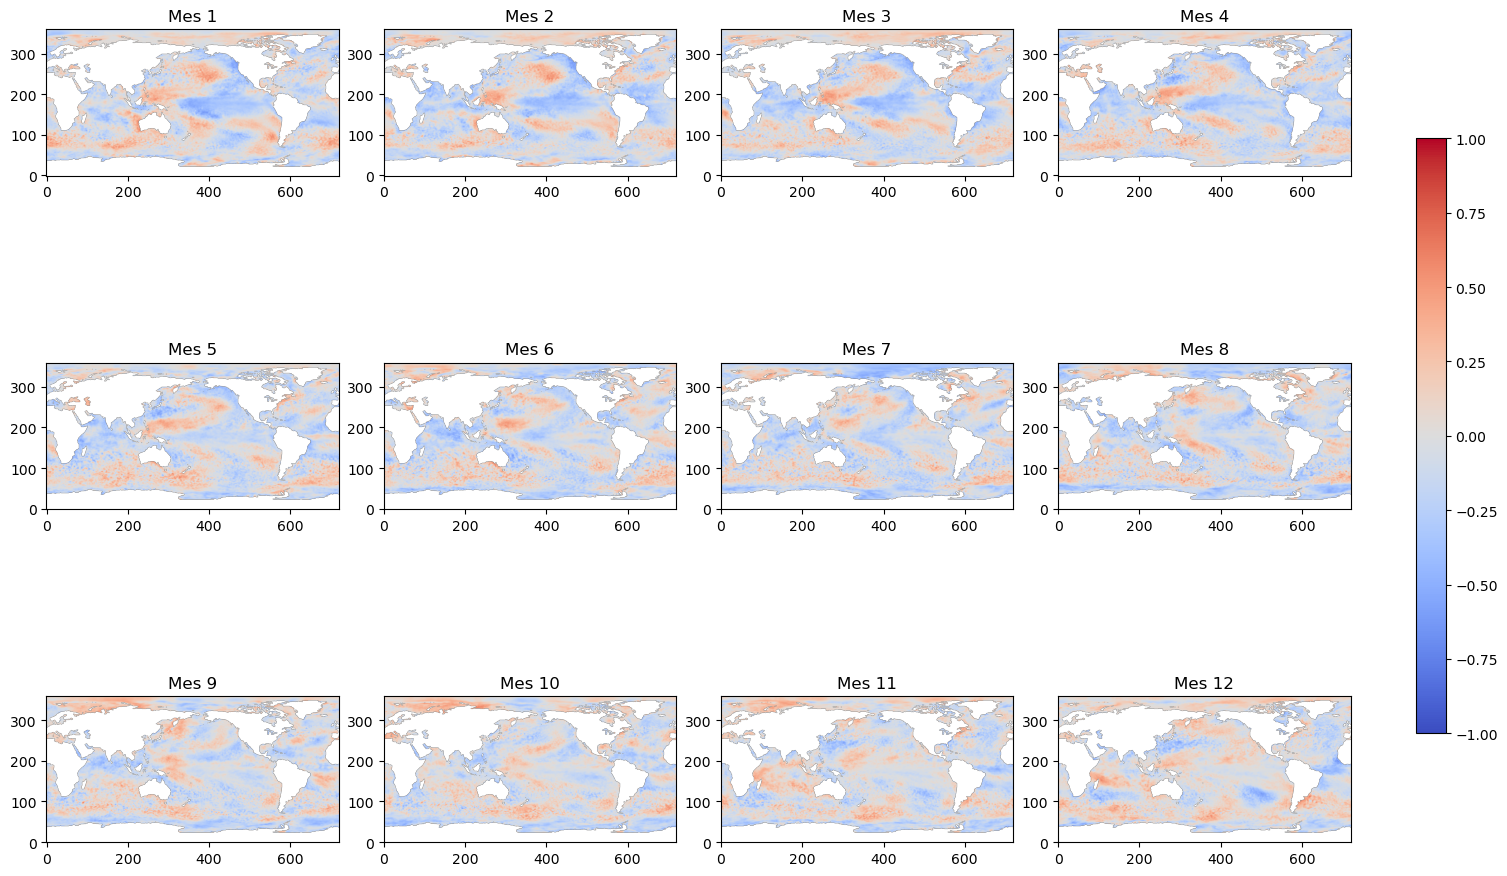

In [7]:
import xarray as xr
import matplotlib.pyplot as plt

path = r"C:\Users\paola\Tesis\03_Resultados\Correlaciones_fast\rice_batches\rice_batch_1.nc"
ds = xr.open_dataset(path)

i = 0  # punto del batch
data = ds[f"corr_{i}"]  # cubo completo

# Graficar los 12 mapas
fig, axes = plt.subplots(3, 4, figsize=(15, 10), constrained_layout=True)

for m, ax in enumerate(axes.flat, start=1):
    mapa = data.sel(month=m)
    im = ax.imshow(mapa, origin='lower', cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(f"Mes {m}")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.show()
